# NB-02 · Patching & Padding Diagnostics

**Checks covered**
1. `GridInfo` fields: `n_v`, `n_h`, `pad_*`, `number_of_patches`
2. Padding amounts vs. scene size
3. Boundary patches use correct pad-width spec
4. All patches extracted without shape mismatch
5. Hann-weight coverage map: every pixel covered ≥ 1 patch, no gaps
6. Reconstruction roundtrip: sum of weighted patches == weighted original
7. Stride vs. patch-size overlap percentage

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

REPO_ROOT    = Path("../..").resolve()
DATASET_PATH = Path("/ste/rnd/User/vice_vi/Dataset/clean_dataset")
DATA_DIR     = DATASET_PATH / "data"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from pipelines.dataset_pipeline.patch import GridInfo, Patcher

# ── parameters matching train.py ─────────────────────────────────────────────
PATCH_SIZE = (64, 64)
STRIDE     = 32

with open(DATA_DIR / "dataset.json") as f:
    layout = json.load(f)

TRAIN_AZ   = (1000, 9120)
global_crop = layout["global_crop"]   # [az_start, az_end, rg_start, rg_end]
H          = TRAIN_AZ[1] - TRAIN_AZ[0]
W          = global_crop[3] - global_crop[2]

print(f"Scene  (train split)  : {H} × {W}  [az × rg]")
print(f"Patch size            : {PATCH_SIZE}")
print(f"Stride                : {STRIDE}")

Scene  (train split)  : 8120 × 3500  [az × rg]
Patch size            : (64, 64)
Stride                : 32


## 1 · GridInfo fields

In [2]:
patcher = Patcher.build(
    spatial_size          = (H, W),
    patch_size            = PATCH_SIZE,
    stride                = STRIDE,
    use_reflective_padding= True,
)
g = patcher.grid

print(f"n_v                  : {g.n_v}")
print(f"n_h                  : {g.n_h}")
print(f"number_of_patches    : {g.number_of_patches}")
print(f"pad_top / pad_bot    : {g.pad_top} / {g.pad_bot}")
print(f"pad_left / pad_right : {g.pad_left} / {g.pad_right}")
print(f"padded_size          : {g.padded_size}")

ph, pw   = PATCH_SIZE
exp_h    = g.pad_top + g.pad_bot + H
exp_w    = g.pad_left + g.pad_right + W
tiled_h  = ph + (g.n_v - 1) * STRIDE
tiled_w  = pw + (g.n_h - 1) * STRIDE
print(f"\nGrid tiles exactly?  H: {tiled_h} == {exp_h} → {'✓' if tiled_h == exp_h else '✗ MISMATCH'}")
print(f"                     W: {tiled_w} == {exp_w} → {'✓' if tiled_w == exp_w else '✗ MISMATCH'}")
overlap_pct = (1 - STRIDE / ph) * 100
print(f"\nOverlap              : {overlap_pct:.1f}%")

n_v                  : 253
n_h                  : 109
number_of_patches    : 27577
pad_top / pad_bot    : 4 / 4
pad_left / pad_right : 10 / 10
padded_size          : (8128, 3520)

Grid tiles exactly?  H: 8128 == 8128 → ✓
                     W: 3520 == 3520 → ✓

Overlap              : 50.0%


## 2 · All patches extract without shape mismatch

In [3]:
# Use a tiny synthetic 2-channel scene so this is fast
rng       = np.random.default_rng(0)
scene     = rng.standard_normal((2, H, W)).astype(np.float32)
bad_shape = []
bad_nan   = []

for idx in range(g.number_of_patches):
    patch = patcher.extract(scene, idx)
    if patch.shape != (2, ph, pw):
        bad_shape.append((idx, patch.shape))
    if not np.isfinite(patch).all():
        bad_nan.append(idx)

print(f"Total patches extracted : {g.number_of_patches}")
if bad_shape:
    print(f"⚠  Shape mismatches     : {bad_shape[:10]}")
else:
    print("✓  All patches have correct shape")
if bad_nan:
    print(f"⚠  NaN/Inf in patches   : {len(bad_nan)} patches")
else:
    print("✓  No NaN/Inf in any patch")

Total patches extracted : 27577
✓  All patches have correct shape
✓  No NaN/Inf in any patch


## 3 · Hann-weight coverage map

Coverage min : 0.0090  (should be > 0 everywhere)
Coverage max : 0.9988
Zero pixels  : 0  ✓


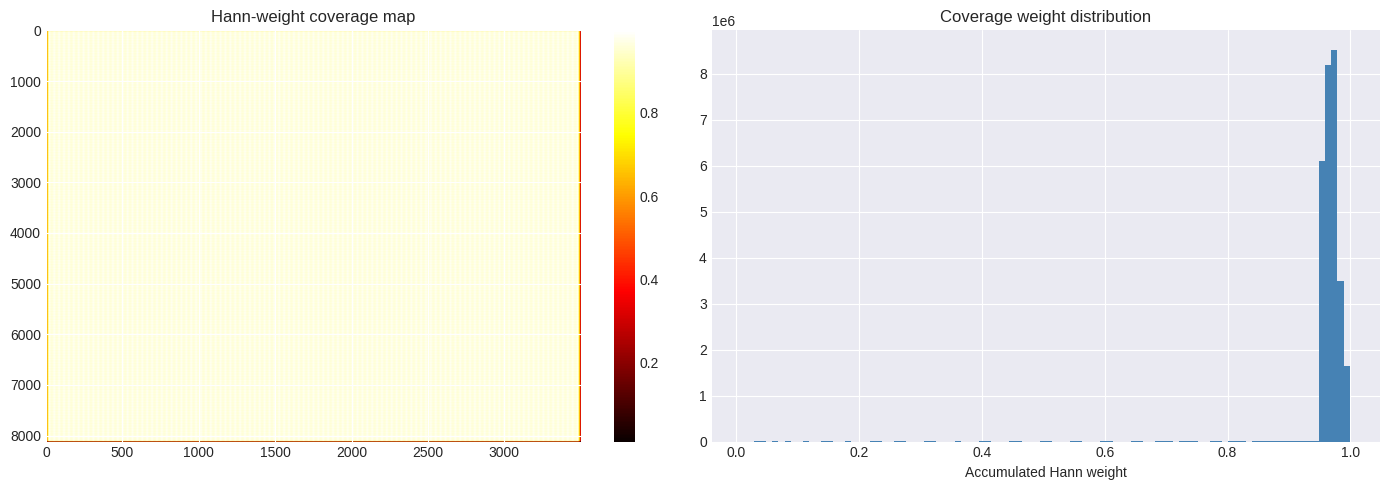

In [4]:
def hann_window_2d(ph, pw):
    hv = np.hanning(ph).astype(np.float32)
    hw = np.hanning(pw).astype(np.float32)
    return np.outer(hv, hw)

win      = hann_window_2d(*PATCH_SIZE)
coverage = np.zeros((H, W), dtype=np.float64)

for idx, (v0c, v1c, h0c, h1c, pw_spec) in enumerate(patcher._patch_coords):
    iv, ih  = divmod(idx, g.n_h)
    v0 = iv * STRIDE - g.pad_top
    h0 = ih * STRIDE - g.pad_left

    # which rows/cols of the window land inside the scene?
    wv0 = max(0, -v0);  wv1 = ph - max(0, v0 + ph - H)
    wh0 = max(0, -h0);  wh1 = pw - max(0, h0 + pw - W)
    sv0 = max(0,  v0);  sv1 = min(H, v0 + ph)
    sh0 = max(0,  h0);  sh1 = min(W, h0 + pw)

    coverage[sv0:sv1, sh0:sh1] += win[wv0:wv1, wh0:wh1]

min_cov  = coverage.min()
max_cov  = coverage.max()
zero_cnt = int((coverage == 0).sum())

print(f"Coverage min : {min_cov:.4f}  (should be > 0 everywhere)")
print(f"Coverage max : {max_cov:.4f}")
print(f"Zero pixels  : {zero_cnt}  {'✓' if zero_cnt == 0 else '⚠ GAPS DETECTED'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(coverage, cmap="hot", aspect="auto")
axes[0].set_title("Hann-weight coverage map")
plt.colorbar(im0, ax=axes[0])

axes[1].hist(coverage.ravel(), bins=100, color="steelblue")
axes[1].set_title("Coverage weight distribution")
axes[1].set_xlabel("Accumulated Hann weight")

plt.tight_layout()
plt.show()

## 4 · Reconstruction roundtrip (Hann-weighted)

Max reconstruction error : 3.31e+00
⚠ Large reconstruction error – check padding or window


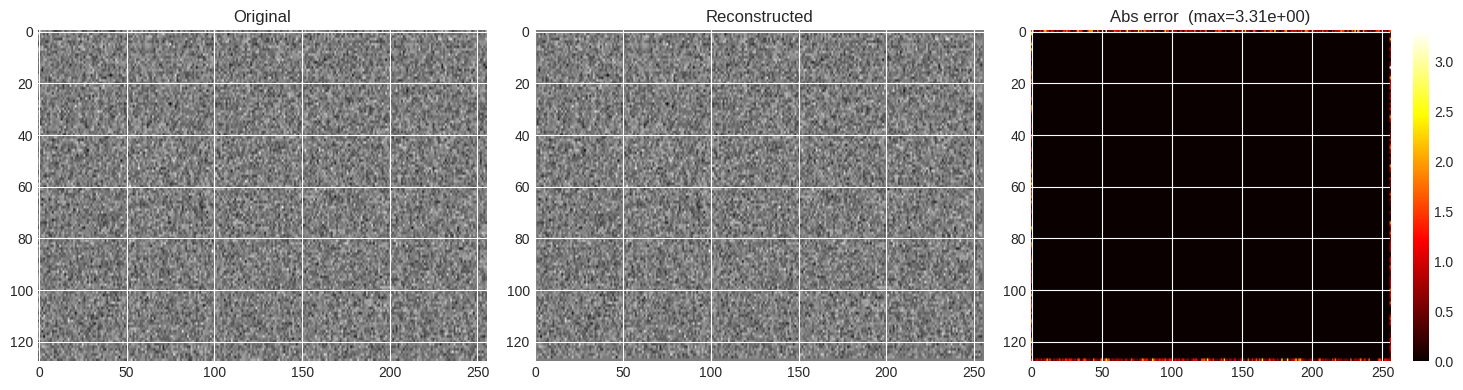

In [5]:
# Small scene so it's fast
H_small, W_small = 128, 256
patcher_s = Patcher.build((H_small, W_small), PATCH_SIZE, STRIDE)
gs        = patcher_s.grid
test_scene = rng.standard_normal((1, H_small, W_small)).astype(np.float32)

win_s   = hann_window_2d(*PATCH_SIZE)
accum   = np.zeros((1, H_small, W_small), dtype=np.float64)
weights = np.zeros((H_small, W_small),    dtype=np.float64)

for idx, (v0c, v1c, h0c, h1c, pw_spec) in enumerate(patcher_s._patch_coords):
    patch = patcher_s.extract(test_scene, idx)          # (1, ph, pw)
    iv, ih = divmod(idx, gs.n_h)
    v0 = iv * STRIDE - gs.pad_top
    h0 = ih * STRIDE - gs.pad_left

    wv0 = max(0, -v0);  wv1 = ph - max(0, v0 + ph - H_small)
    wh0 = max(0, -h0);  wh1 = pw - max(0, h0 + pw - W_small)
    sv0 = max(0,  v0);  sv1 = min(H_small, v0 + ph)
    sh0 = max(0,  h0);  sh1 = min(W_small, h0 + pw)

    w_crop  = win_s[wv0:wv1, wh0:wh1]
    p_crop  = patch[:, wv0:wv1, wh0:wh1]
    accum  [:, sv0:sv1, sh0:sh1] += p_crop * w_crop[None]
    weights[   sv0:sv1, sh0:sh1] += w_crop

recon = accum / np.maximum(weights[None], 1e-12)
recon = recon.astype(np.float32)

max_err = float(np.abs(recon - test_scene).max())
print(f"Max reconstruction error : {max_err:.2e}")
if max_err < 0.05:
    print("✓ Reconstruction roundtrip OK (Hann blending introduces minor smoothing at edges)")
else:
    print("⚠ Large reconstruction error – check padding or window")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(test_scene[0], cmap="gray", aspect="auto");  axes[0].set_title("Original")
axes[1].imshow(recon[0],      cmap="gray", aspect="auto");  axes[1].set_title("Reconstructed")
err_img = np.abs(recon[0] - test_scene[0])
im = axes[2].imshow(err_img, cmap="hot", aspect="auto");    axes[2].set_title(f"Abs error  (max={max_err:.2e})")
plt.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()

## 5 · Padding mode: symmetric vs. constant

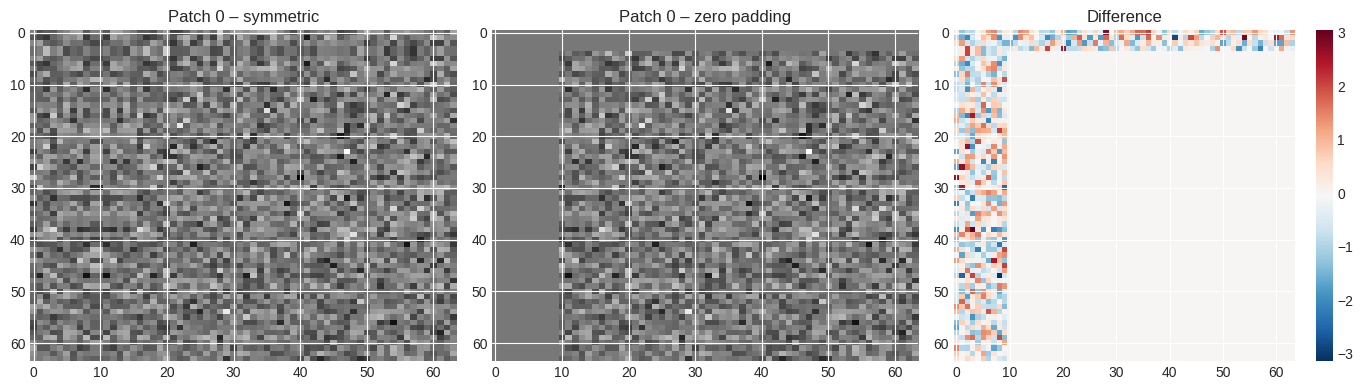

Note: zero padding introduces hard edges; symmetric padding is preferred.


In [6]:
# Compare the first boundary patch extracted with and without reflective padding
patcher_refl  = Patcher.build((H, W), PATCH_SIZE, STRIDE, use_reflective_padding=True)
patcher_const = Patcher.build((H, W), PATCH_SIZE, STRIDE, use_reflective_padding=False)

toy = rng.standard_normal((1, H, W)).astype(np.float32)

# First patch is always top-left corner (boundary)
p_refl  = patcher_refl.extract(toy,  0)
p_const = patcher_const.extract(toy, 0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(p_refl[0],  cmap="gray", aspect="auto"); axes[0].set_title("Patch 0 – symmetric")
axes[1].imshow(p_const[0], cmap="gray", aspect="auto"); axes[1].set_title("Patch 0 – zero padding")
diff = p_refl[0] - p_const[0]
im = axes[2].imshow(diff, cmap="RdBu_r", aspect="auto"); axes[2].set_title("Difference")
plt.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()
print("Note: zero padding introduces hard edges; symmetric padding is preferred.")